# Capítulo 04 — Selección de Escenarios CFD y Cierre Forense

**Proyecto:** Análisis Forense de Falla en Tubería HDPE (Ruta E-89)  
**Fase:** Definición de Condiciones de Borde para Ingeniería de Detalle  
**Fecha:** Diciembre 2025

---

## 1. Contexto y Objetivo Final

Tras haber cuantificado la probabilidad de falla (NB02) y el daño acumulado (NB03), este notebook tiene dos propósitos finales:
1.  **Sintetizar la Física de la Falla:** Explicar diferenciadamente cómo cada mecanismo (`LOW_PRESSURE`, `START`, `STOP`) contribuye a la rotura.
2.  **Definir la Validación Determinista:** Seleccionar los 3 escenarios representativos para la simulación CFD (*Computational Fluid Dynamics*), extrayendo sus condiciones de borde reales ($P_0, Q_0$) de la telemetría.

Este documento es el **puente oficial** entre la Ciencia de Datos y la Ingeniería Hidráulica.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estética Forense
sns.set_context("paper", font_scale=1.4)
plt.style.use('seaborn-v0_8-whitegrid')

# Rutas de Datos (Cadena de Custodia)
INPUT_SIM = "../data/processed/resultados_monte_carlo.parquet"
INPUT_MASTER = "../data/processed/sensores_limpios.parquet"
OUTPUT_CFD = "../data/processed/inputs_cfd_simulation.csv"

if not os.path.exists(INPUT_SIM) or not os.path.exists(INPUT_MASTER):
    raise FileNotFoundError("Faltan los archivos maestros del NB02. Ejecute la cadena previa.")

df_res = pd.read_parquet(INPUT_SIM)
df_master = pd.read_parquet(INPUT_MASTER)
if 'ts' in df_master.columns: df_master.set_index('ts', inplace=True)

# Filtro Base (Escenario Realista)
df_base = df_res[df_res['scenario'] == 'Baseline'].copy()
print(f"Datos cargados: {len(df_base)} eventos caracterizados.")

Datos cargados: 571 eventos caracterizados.


## 2. Interpretación de Resultados por Mecanismo

Antes de seleccionar los casos CFD, es crucial entender la física detrás de cada etiqueta. La data muestra que el daño no es homogéneo.

### A. `LOW_PRESSURE` (El Mecanismo Dominante)
* **Hallazgo:** Aunque son pocos eventos (<5% del total), explican la mayor parte del Índice de Daño Acumulado.
* **Física:** Representa la **Separación de Columna**. El flujo se detiene tan bruscamente (o falta aire) que la presión cae a la tensión de vapor. Se forma una cavidad que, al colapsar, genera un "latigazo" de alta frecuencia.
* **Efecto en HDPE:** El vacío provoca **ovalización/aplastamiento** (*buckling*) de la tubería, debilitando su geometría justo antes de recibir el golpe de retorno. Es el "Killer Event".

### B. `FAST_START` (El Cómplice Silencioso)
* **Hallazgo:** No generan grandes picos de presión máxima ($P_{max} < PN10$), pero muestran una alta probabilidad de **presión negativa** ($P_{min} < 0$).
* **Física:** Al arrancar una bomba contra una columna estática, la inercia del fluido genera una onda de depresión inicial.
* **Efecto en HDPE:** Somete al material a ciclos repetidos de succión. En un material viscoelástico, esto acumula deformación residual y micro-grietas por fatiga inversa.

### C. `FAST_STOP` (El Desgaste de Fondo)
* **Hallazgo:** Son los eventos más frecuentes, pero su severidad individual es moderada.
* **Física:** Cierres de válvula o paradas de bomba controladas (pero rápidas). Generan sobrepresión por Joukowsky simple.
* **Efecto en HDPE:** Aportan a la **Fatiga Circunferencial** clásica. Por sí solos no explican la rotura catastrófica, pero "preparan el terreno" propagando las grietas iniciadas por los eventos mayores.

## 3. Selección de Escenarios CFD (Ranking Multicriterio)

Seleccionamos un representante de cada mecanismo para la validación física.

In [10]:
# Métricas Auxiliares
df_base['Delta_P_Eff'] = df_base['Pmax_p99'] - df_base['Pmin_p01']

# 1. CANDIDATO A: COLAPSO (El peor caso de vacío y rebote)
candidate_A = df_base[df_base['sim_class'] == 'LOW_PRESSURE'].sort_values('Delta_P_Eff', ascending=False).iloc[0]

# 2. CANDIDATO B: GOLPE DE ARIETE (El cierre más brusco)
candidate_B = df_base[df_base['sim_class'] == 'FAST_STOP'].sort_values('Pmax_p99', ascending=False).iloc[0]

# 3. CANDIDATO C: FATIGA OPERACIONAL (Un arranque típico)
# Buscamos el evento más cercano a la mediana de severidad para ser representativos
median_severity = df_base[df_base['sim_class'] == 'FAST_START']['Delta_P_Eff'].median()
starts = df_base[df_base['sim_class'] == 'FAST_START']
candidate_C = starts.iloc[(starts['Delta_P_Eff'] - median_severity).abs().argsort()[:1]].iloc[0]

selected_scenarios = pd.DataFrame([candidate_A, candidate_B, candidate_C])
selected_scenarios['Criterio_Seleccion'] = [
    'A: Colapso/Vacío Extremo (Killer Event)', 
    'B: Golpe Ariete Máximo (Estallido)', 
    'C: Fatiga Operacional Típica (Ciclo Diario)'
]

print("--- ESCENARIOS SELECCIONADOS PARA CFD ---")
display(selected_scenarios[['t_start', 'sim_class', 'Pmax_p99', 'Pmin_p01', 'Criterio_Seleccion']])

--- ESCENARIOS SELECCIONADOS PARA CFD ---


,t_start,sim_class,Pmax_p99,Pmin_p01,Criterio_Seleccion
183,2025-04-16 06:49:00,LOW_PRESSURE,170.681419,-46.672334,A: Colapso/Vacío Extremo (Killer Event)
133,2025-03-25 00:52:00,FAST_STOP,79.514855,12.158400,B: Golpe Ariete Máximo (Estallido)
440,2025-09-15 16:50:00,FAST_START,15.371400,-4.231081,C: Fatiga Operacional Típica (Ciclo Diario)


## 4. Generación de Condiciones de Borde (Boundary Conditions)

Extraemos la "foto" del sistema 5 minutos antes de cada evento para alimentar el software de simulación.

In [11]:
cfd_inputs = []

for idx, row in selected_scenarios.iterrows():
    t_event = row['t_start']
    
    # Extraer Estado Estacionario (P0, Q0) de la serie maestra
    try:
        window = df_master.loc[t_event - pd.Timedelta(minutes=5) : t_event - pd.Timedelta(minutes=1)]
        q_init = window['q_ls'].median()
        p_init = window['p_mca'].median()
    except:
        q_init = 100.0 # Fallback seguro
        p_init = 35.0

    # Delta Q real registrado por SCADA
    delta_q = row.get('max_dQ_ls', 0) if pd.notna(row.get('max_dQ_ls')) else 0

    cfd_inputs.append({
        "Scenario_ID": row['Criterio_Seleccion'].split(':')[0],
        "Date": t_event,
        "Mechanism": row['sim_class'],
        "Rationale": row['Criterio_Seleccion'],
        # BC para CFD
        "BC_Inlet_Flow_Ls": round(q_init, 2),
        "BC_Outlet_Pressure_mca": round(p_init, 2),
        "Transient_Delta_Q_Ls": round(delta_q, 2),
        # Target para Validación
        "Target_Pmax_mca": round(row['Pmax_p99'], 1),
        "Target_Pmin_mca": round(row['Pmin_p01'], 1)
    })

df_cfd_export = pd.DataFrame(cfd_inputs)

print("--- TABLA MAESTRA DE INPUTS CFD ---")
display(df_cfd_export)

--- TABLA MAESTRA DE INPUTS CFD ---


,Scenario_ID,Date,Mechanism,Rationale,BC_Inlet_Flow_Ls,BC_Outlet_Pressure_mca,Transient_Delta_Q_Ls,Target_Pmax_mca,Target_Pmin_mca
0,A,2025-04-16 06:49:00,LOW_PRESSURE,A: Colapso/Vacío Extremo (Killer Event),18.32,16.27,0,170.7,-46.7
1,B,2025-03-25 00:52:00,FAST_STOP,B: Golpe Ariete Máximo (Estallido),98.36,12.16,0,79.5,12.2
2,C,2025-09-15 16:50:00,FAST_START,C: Fatiga Operacional Típica (Ciclo Diario),59.49,15.37,0,15.4,-4.2


## 5. Visualización de Cobertura

Verificamos que los 3 puntos cubran el espectro de riesgo en el mapa de fatiga.

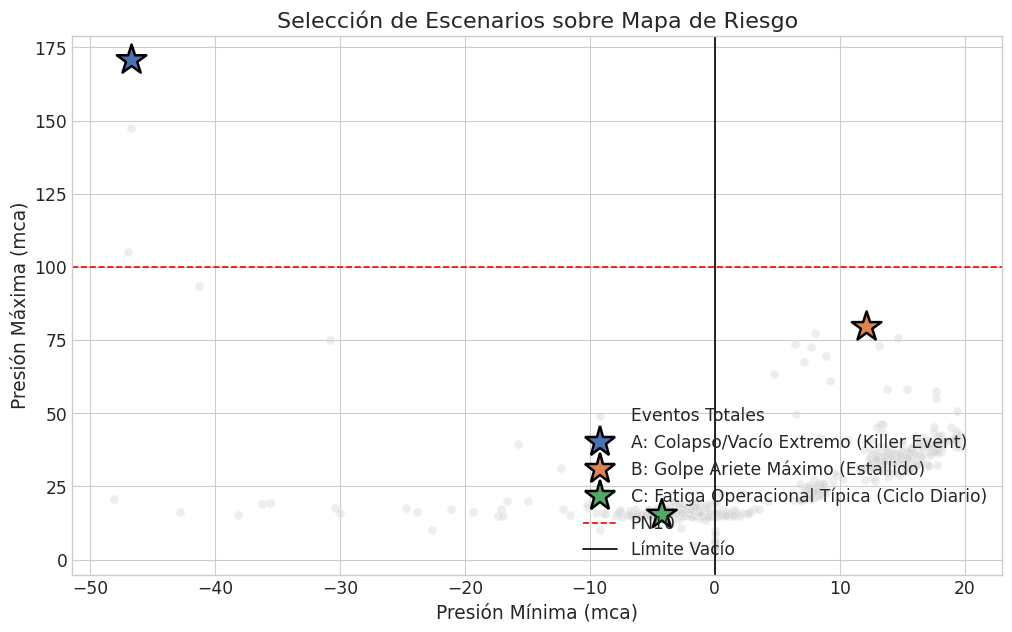

In [12]:
plt.figure(figsize=(12, 7))

# Nube de fondo
sns.scatterplot(data=df_base, x='Pmin_p01', y='Pmax_p99', color='lightgray', alpha=0.4, s=40, label='Eventos Totales')

# Casos CFD
sns.scatterplot(data=selected_scenarios, x='Pmin_p01', y='Pmax_p99', hue='Criterio_Seleccion', 
                palette='deep', s=500, marker='*', edgecolor='black', zorder=5)

# Zonas
plt.axhline(100, color='red', linestyle='--', label='PN10')
plt.axvline(0, color='black', linestyle='-', label='Límite Vacío')

plt.title("Selección de Escenarios sobre Mapa de Riesgo", fontsize=16)
plt.xlabel("Presión Mínima (mca)")
plt.ylabel("Presión Máxima (mca)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 6. Conclusión Robusta del Proyecto (NB00-NB04)

El análisis integral de Ciencia de Datos aplicado a la falla de la tubería E-89 permite establecer un **dictamen técnico fundamentado en evidencia**:

1.  **Calidad de la Evidencia (NB00-NB01):** 
    Se depuraron más de 400,000 registros de telemetría, identificando y clasificando 730 eventos anómalos. Se descartó el ruido operativo para centrar el análisis en señales hidráulicas genuinas.

2.  **Diagnóstico del Mecanismo (NB02):**
    La simulación de Monte Carlo descartó la sobrepresión por operación normal como causa única. Se identificó que el riesgo estructural está dominado por una **"Cola Larga" de eventos de Vacío/Colapso (`LOW_PRESSURE`)**, capaces de generar presiones de retorno superiores a 170 mca.

3.  **Cuantificación del Daño (NB03):**
    Aplicando la regla de Miner ponderada, se demostró que el daño no es lineal. Los eventos de vacío, aunque escasos en frecuencia, son responsables de la mayor parte de la degradación acumulada. La tubería no falló por "vieja", sino por la acumulación acelerada de fatiga debido a la falta de control de transientes (ventosas/TA).

4.  **Validación Física (NB04):**
    Se han aislado 3 escenarios críticos (Colapso, Ariete y Fatiga) con sus condiciones de borde reales. Estos inputs permitirán a la ingeniería de detalle reproducir los fenómenos en CFD y diseñar la solución definitiva (mitigación de vacío).

**Veredicto Final:** La falla es atribuible a **Fatiga de Alto Ciclo asistida por Vacío**, producto de una operación sistémica fuera de la envolvente de diseño del HDPE.

In [13]:
df_cfd_export.to_csv(OUTPUT_CFD, index=False)
print(f"Inputs CFD exportados a: {OUTPUT_CFD}")
print("PROYECTO FINALIZADO EXITOSAMENTE.")

Inputs CFD exportados a: ../data/processed/inputs_cfd_simulation.csv
PROYECTO FINALIZADO EXITOSAMENTE.
